<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning & Deep Learning</b></center>

<center><b><h1>Lab - 6</b></center>    
<pre>    

# SVR

# Importing the libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

# Read World bank CSV

In [2]:
df = pd.read_csv("WorldBank.csv")

In [3]:
df

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
0,India,IND,Export value index (2000 = 100),TX.VAL.MRCH.XD.WD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.147485e+02,7.004085e+02,7.429281e+02,7.614417e+02,6.322694e+02,6.242250e+02,7.061028e+02,7.663608e+02,NaN,NaN
1,India,IND,Insurance and financial services (% of commerc...,TX.VAL.INSF.ZS.WT,NaN,NaN,NaN,NaN,NaN,NaN,...,6.403614e+00,5.246771e+00,5.729495e+00,5.060904e+00,4.706801e+00,4.471147e+00,3.760466e+00,3.921611e+00,3.438072e+00,NaN
2,India,IND,"Merchandise imports by the reporting economy, ...",TM.VAL.MRCH.RS.ZS,4.983551,6.488050e+00,1.012461e+01,9.451370e+00,1.052948e+01,1.089112e+01,...,7.550664e-01,2.738416e-01,4.409538e-01,1.514439e+00,2.228351e+00,2.270593e+00,1.770314e+00,5.354193e-01,NaN,NaN
3,India,IND,Food imports (% of merchandise imports),TM.VAL.FOOD.ZS.UN,NaN,NaN,1.708001e+01,1.519791e+01,1.686304e+01,2.200813e+01,...,3.741041e+00,4.048246e+00,3.895215e+00,4.458509e+00,5.758038e+00,6.505293e+00,6.137617e+00,4.156488e+00,4.248261e+00,NaN
4,India,IND,Share of tariff lines with international peaks...,TM.TAX.MRCH.IP.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.434346e+00,8.641136e+00,8.576307e+00,NaN,5.802677e+00,7.707811e+00,8.288774e+00,9.111423e+00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,India,IND,"Foreign direct investment, net inflows (% of GDP)",BX.KLT.DINV.WD.GD.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,2.002065e+00,1.312934e+00,1.516276e+00,1.695659e+00,2.092116e+00,1.937363e+00,1.506588e+00,1.552336e+00,1.760283e+00,NaN
1436,India,IND,"Net capital account (BoP, current US$)",BN.TRF.KOGT.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,6.791581e+07,-5.972328e+08,9.618297e+08,-7.433364e+07,3.706943e+07,1.368359e+08,3.731153e+07,-1.231007e+08,-1.155591e+09,NaN
1437,India,IND,"Travel services (% of service imports, BoP)",BM.GSR.TRVL.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,1.761773e+01,1.544257e+01,1.475397e+01,1.799216e+01,1.795378e+01,1.707263e+01,1.686302e+01,1.716750e+01,1.755462e+01,NaN
1438,India,IND,Cereal production (metric tons),AG.PRD.CREL.MT,NaN,8.737650e+07,8.725755e+07,9.037301e+07,9.370600e+07,7.969950e+07,...,2.878600e+08,2.932900e+08,2.949095e+08,2.960100e+08,2.843330e+08,2.978500e+08,3.136100e+08,NaN,NaN,NaN


# Perform conditional selection to find - Population ages 15-64 (% of total population)

In [4]:
data = df[df["Indicator Name"] == "Population ages 15-64 (% of total population)"]

data.head(10)
india = data[data["Country Name"] == "India"]

india

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
9,India,IND,Population ages 15-64 (% of total population),SP.POP.1564.TO.ZS,56.49748,56.177532,55.807455,55.461664,55.248939,55.211351,...,64.429404,64.805519,65.208489,65.59598,65.944164,66.274262,66.538187,66.766743,67.003811,NaN


# Divide the data into input and output

In [15]:
X = india.columns[4:].astype(int).values.reshape(-1,1)

In [10]:
y = india.iloc[0,4:].values

In [16]:
X

array([[1960],
       [1961],
       [1962],
       [1963],
       [1964],
       [1965],
       [1966],
       [1967],
       [1968],
       [1969],
       [1970],
       [1971],
       [1972],
       [1973],
       [1974],
       [1975],
       [1976],
       [1977],
       [1978],
       [1979],
       [1980],
       [1981],
       [1982],
       [1983],
       [1984],
       [1985],
       [1986],
       [1987],
       [1988],
       [1989],
       [1990],
       [1991],
       [1992],
       [1993],
       [1994],
       [1995],
       [1996],
       [1997],
       [1998],
       [1999],
       [2000],
       [2001],
       [2002],
       [2003],
       [2004],
       [2005],
       [2006],
       [2007],
       [2008],
       [2009],
       [2010],
       [2011],
       [2012],
       [2013],
       [2014],
       [2015],
       [2016],
       [2017],
       [2018],
       [2019],
       [2020]])

In [13]:
y

array([np.float64(56.49748004), np.float64(56.17753236),
       np.float64(55.80745463), np.float64(55.46166361),
       np.float64(55.24893881), np.float64(55.21135053),
       np.float64(55.09090078), np.float64(55.15534672),
       np.float64(55.34507283), np.float64(55.57014408),
       np.float64(55.78194745), np.float64(55.85676846),
       np.float64(55.95268174), np.float64(56.07247186),
       np.float64(56.23447551), np.float64(56.44405309),
       np.float64(56.49722595), np.float64(56.62068516),
       np.float64(56.78900152), np.float64(56.9691436),
       np.float64(57.1425581), np.float64(57.18105454),
       np.float64(57.22630775), np.float64(57.28875038),
       np.float64(57.39054366), np.float64(57.54142108),
       np.float64(57.55350984), np.float64(57.6545119),
       np.float64(57.81875323), np.float64(58.01501187),
       np.float64(58.22990246), np.float64(58.37403848),
       np.float64(58.5472698), np.float64(58.75605047),
       np.float64(59.012126), np.fl

# Plot scatter plot of Population ages 15-64 (% of total population)

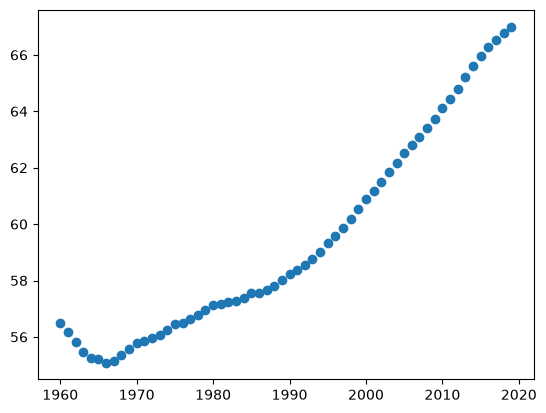

In [14]:
plt.scatter(X,y)

# Splitting the dataset into the Training set and Test set

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [22]:
X_train

array([[2001],
       [1993],
       [2003],
       [2009],
       [1967],
       [1974],
       [1992],
       [2011],
       [1989],
       [2002],
       [2015],
       [1978],
       [2017],
       [1987],
       [1975],
       [1965],
       [1991],
       [1976],
       [2012],
       [1980],
       [2018],
       [1968],
       [1973],
       [1985],
       [1997],
       [1977],
       [2005],
       [2008],
       [2014],
       [1998],
       [1961],
       [1972],
       [2006],
       [1984],
       [1966],
       [1983],
       [1996],
       [2010],
       [1981],
       [1979],
       [1969],
       [1999],
       [2016],
       [1963],
       [1960],
       [2013],
       [2007],
       [2004]])

In [23]:
y_train

array([np.float64(61.18898716), np.float64(58.75605047),
       np.float64(61.83084479), np.float64(63.74196691),
       np.float64(55.15534672), np.float64(56.23447551),
       np.float64(58.5472698), np.float64(64.429404),
       np.float64(58.01501187), np.float64(61.4993847),
       np.float64(65.94416405), np.float64(56.78900152),
       np.float64(66.53818711), np.float64(57.6545119),
       np.float64(56.44405309), np.float64(55.21135053),
       np.float64(58.37403848), np.float64(56.49722595),
       np.float64(64.80551944), np.float64(57.1425581),
       np.float64(66.7667425), np.float64(55.34507283),
       np.float64(56.07247186), np.float64(57.54142108),
       np.float64(59.8572303), np.float64(56.62068516),
       np.float64(62.52276485), np.float64(63.40924784),
       np.float64(65.5959799), np.float64(60.18600058),
       np.float64(56.17753236), np.float64(55.95268174),
       np.float64(62.80842981), np.float64(57.39054366),
       np.float64(55.09090078), np.float

# Feature Scaling (Mandatory for SVR)**
SVR is highly sensitive to the range of data points. If we don't scale (normalize) the data, the model will fail to find the correct hyperplane.

In [27]:
sc_X = StandardScaler()
sc_y = StandardScaler()

X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

y_train = sc_y.fit_transform(y_train.reshape(-1,1))

In [28]:
X_train

array([[ 0.59393694],
       [ 0.13687925],
       [ 0.70820136],
       [ 1.05099462],
       [-1.34855822],
       [-0.94863275],
       [ 0.07974704],
       [ 1.16525905],
       [-0.09164959],
       [ 0.65106915],
       [ 1.39378789],
       [-0.7201039 ],
       [ 1.50805231],
       [-0.20591401],
       [-0.89150054],
       [-1.46282264],
       [ 0.02261483],
       [-0.83436833],
       [ 1.22239126],
       [-0.60583948],
       [ 1.56518452],
       [-1.29142601],
       [-1.00576496],
       [-0.32017843],
       [ 0.3654081 ],
       [-0.77723612],
       [ 0.82246578],
       [ 0.99386241],
       [ 1.33665568],
       [ 0.42254031],
       [-1.69135149],
       [-1.06289717],
       [ 0.87959799],
       [-0.37731064],
       [-1.40569043],
       [-0.43444285],
       [ 0.30827589],
       [ 1.10812684],
       [-0.54870727],
       [-0.66297169],
       [-1.2342938 ],
       [ 0.47967252],
       [ 1.4509201 ],
       [-1.57708706],
       [-1.7484837 ],
       [ 1

In [29]:
y_train

array([[ 0.40125937],
       [-0.25879029],
       [ 0.57539374],
       [ 1.0938764 ],
       [-1.23565223],
       [-0.94288729],
       [-0.31543196],
       [ 1.28037637],
       [-0.45983221],
       [ 0.48546944],
       [ 1.691327  ],
       [-0.79244576],
       [ 1.85248397],
       [-0.55763495],
       [-0.88602941],
       [-1.22045854],
       [-0.36242919],
       [-0.87160375],
       [ 1.38241555],
       [-0.69652674],
       [ 1.91449048],
       [-1.18418001],
       [-0.98683847],
       [-0.58831621],
       [ 0.03995705],
       [-0.83810957],
       [ 0.76310993],
       [ 1.00361055],
       [ 1.5968655 ],
       [ 0.12915161],
       [-0.95833582],
       [-1.01933723],
       [ 0.84061012],
       [-0.62924888],
       [-1.25313626],
       [-0.65686514],
       [-0.03930442],
       [ 1.19323738],
       [-0.68608276],
       [-0.74357366],
       [-1.12311874],
       [ 0.2251135 ],
       [ 1.78088187],
       [-1.15254923],
       [-0.87153481],
       [ 1

# Fitting SVR on 3 Different Kernel on dataset

In [32]:
svr_linear = SVR(kernel = "linear")

svr_linear.fit(X_train, y_train.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [33]:
svr_poly = SVR(kernel = "poly", degree = 3)

svr_poly.fit(X_train, y_train.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [34]:
svr_rbf = SVR(kernel = "rbf")

svr_rbf.fit(X_train, y_train.ravel())

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


# Predict the x_test using 3 Kernel

In [35]:
y_pred_linear = svr_linear.predict(X_test)

In [36]:
y_pred_poly = svr_poly.predict(X_test)

In [37]:
y_pred_rbf = svr_rbf.predict(X_test)

In [38]:
y_pred_linear

array([1941.8420433 , 1950.64200784, 1975.08635377, 1943.79759098,
       1927.17543575, 1918.37547121, 1949.664234  , 1974.10857993,
       1955.53087703, 1937.93094796, 1920.33101889, 1926.19766191,
       1945.75313865])

In [39]:
y_pred_poly

array([4.35800000e+09, 4.41751663e+09, 4.58567848e+09, 4.37117942e+09,
       4.25999771e+09, 4.20190764e+09, 4.41087708e+09, 4.57887144e+09,
       4.45081435e+09, 4.33172067e+09, 4.21477061e+09, 4.25351699e+09,
       4.38438539e+09])

In [40]:
y_pred_rbf

array([0.14952457, 0.14952457, 0.14952457, 0.14952457, 0.14952457,
       0.14952457, 0.14952457, 0.14952457, 0.14952457, 0.14952457,
       0.14952457, 0.14952457, 0.14952457])

# Visualising the  results

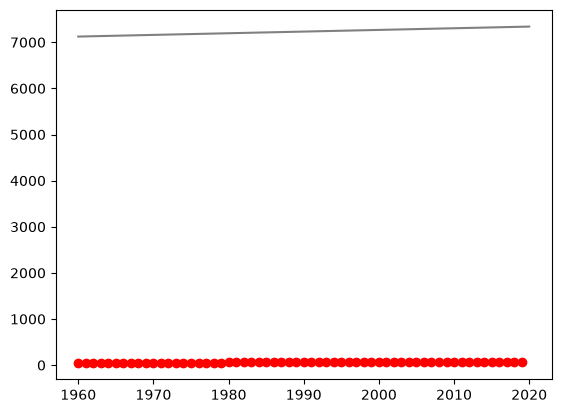

In [45]:
plt.scatter(X, y, color = "red", label = "Actual Data")

plt.plot(X, sc_y.inverse_transform(svr_linear.predict(sc_X.transform(X)).reshape(-1,1)), color = "grey", label = "Linear Kernel")

### **Student Activity : Prediction**
**Task:** Predict the value for the Year **2025** (or value 6.5 in the demo data). 
Remember: You must transform the input before predicting, and inverse transform the output.

The predicted value for input 2025 is: 66.47
